<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 30px; border-radius: 12px; color: white; text-align: center;">
  <h1 style="font-size: 2em; margin: 0;">🚿 SWaT Dataset — Data Analysis</h1>
  <p style="font-size: 1.1em; color: #a8d8ea; margin-top: 10px;">Secure Water Treatment | IoT Anomaly Detection</p>
  <hr style="border-color: #0f3460; margin: 15px 0;">
  <p style="margin: 0; color: #ccc;">Project: Real-Time Anomaly Detection for IoT Sensor Streams | DEPI Initiative</p>
</div>

## 📋 Notebook Outline

| # | Section | Description |
|---|---------|-------------|
| 1 | **Data Understanding** | Load, inspect shape, dtypes, basic stats |
| 2 | **Data Handling** | Missing values, duplicates, type casting |
| 3 | **Label Analysis** | Class distribution & imbalance check |
| 4 | **Sensor Profiling** | Separate continuous sensors vs binary actuators |
| 5 | **EDA & Visualizations** | Time series, distributions, correlations |
| 6 | **Anomaly Pattern Analysis** | Normal vs Attack statistical comparison |
| 7 | **Preprocessing Pipeline** | Normalization + Sliding Windows |
| 8 | **Save & Summary** | Export processed data + EDA report |

---
## 0️⃣ Setup & Imports

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Style 
plt.rcParams.update({
    'figure.figsize'  : (16, 5),
    'font.size'       : 12,
    'axes.titlesize'  : 14,
    'axes.titleweight': 'bold',
    'axes.spines.top' : False,
    'axes.spines.right': False,
})
sns.set_style('darkgrid')
sns.set_palette('husl')

# Color Palette 
C_NORMAL = '#4A90D9'   # blue  → normal
C_ATTACK = '#E74C3C'   # red   → attack / anomaly
C_ACCENT = '#2ECC71'   # green → highlights

print('✅ Setup complete!')
print(f'   Pandas  : {pd.__version__}')
print(f'   NumPy   : {np.__version__}')

✅ Setup complete!
   Pandas  : 2.3.3
   NumPy   : 2.3.5


---
## 1️⃣ Data Understanding

In [ ]:
#  Paths 
NORMAL_PATH = r'E:\DEPI\GIZ4_AIS2_S1\SWAT data set\normal.csv'
ATTACK_PATH = r'E:\DEPI\GIZ4_AIS2_S1\SWAT data set\attack.csv'

#  Smart Loader 
def load_swat(path, name):
    """
    Robust SWaT CSV loader:
    - Auto-detects comma vs semicolon separator
    - Strips whitespace from column names
    - Reports shape and memory usage
    """
    for sep in [',', ';']:
        try:
            df = pd.read_csv(path, sep=sep, low_memory=False)
            if df.shape[1] > 2:          # valid parse → more than 2 columns
                break
        except Exception:
            continue

    df.columns = df.columns.str.strip()
    mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f'✅ [{name}] loaded → {df.shape[0]:,} rows × {df.shape[1]} cols  |  {mem:.1f} MB')
    return df

df_normal = load_swat(NORMAL_PATH, 'Normal')
df_attack = load_swat(ATTACK_PATH, 'Attack')

✅ [Normal] loaded → 1,387,098 rows × 53 cols  |  706.5 MB
✅ [Attack] loaded → 54,621 rows × 53 cols  |  27.8 MB


In [ ]:
# 1.1 Preview 
print('━' * 70)
print('NORMAL DATA — first 5 rows')
print('━' * 70)
display(df_normal.head())

print('\n━' * 70)
print('ATTACK DATA — first 5 rows')
print('━' * 70)
display(df_attack.head())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
NORMAL DATA — first 5 rows
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,28/12/2015 10:00:00 AM,2.427057,522.8467,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.5988,0.000128,1,1,1,Normal
1,28/12/2015 10:00:01 AM,2.446274,522.8860,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.6789,0.000128,1,1,1,Normal
2,28/12/2015 10:00:02 AM,2.489191,522.8467,2.0,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6789,0.000128,1,1,1,Normal
3,28/12/2015 10:00:03 AM,2.534350,522.9645,2.0,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6148,0.000128,1,1,1,Normal
4,28/12/2015 10:00:04 AM,2.569260,523.4748,2.0,2,1,262.0161,8.394514,328.6337,2.443085,...,2,1,250.8812,1.649953,189.5027,0.000128,1,1,1,Normal



━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
ATTACK DATA — first 5 rows
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,28/12/2015 10:29:14 AM,2.493675,817.6742,2,1,1,262.625,8.46533,319.7385,0.0,...,2,1,249.8718,1.681991,188.7977,0.000128,1,1,1,Attack
1,28/12/2015 10:29:15 AM,2.535951,817.9490,2,1,1,262.625,8.46533,319.7385,0.0,...,2,1,249.8718,1.681991,188.7977,0.000128,1,1,1,Attack
2,28/12/2015 10:29:16 AM,2.535951,817.9490,2,1,1,262.625,8.46533,319.7385,0.0,...,2,1,249.8718,1.681991,188.7977,0.000128,1,1,1,Attack
3,28/12/2015 10:29:17 AM,2.569900,818.4592,2,1,1,262.625,8.46533,319.7385,0.0,...,2,1,249.8718,1.681991,188.7977,0.000128,1,1,1,Attack
4,28/12/2015 10:29:18 AM,2.610575,818.8911,2,1,1,262.625,8.46533,319.7385,0.0,...,2,1,250.0801,1.681991,188.9740,0.000128,1,1,1,Attack


In [ ]:
#  1.2 Data Types & Info 
print('━' * 50)
print('NORMAL — dtypes & non-null counts')
print('━' * 50)
df_normal.info()

print('\n━' * 50)
print('ATTACK — dtypes & non-null counts')
print('━' * 50)
df_attack.info()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
NORMAL — dtypes & non-null counts
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1387098 entries, 0 to 1387097
Data columns (total 53 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   Timestamp      1387098 non-null  object 
 1   FIT101         1387098 non-null  float64
 2   LIT101         1387098 non-null  float64
 3   MV101          395298 non-null   float64
 4   P101           1387098 non-null  int64  
 5   P102           1387098 non-null  int64  
 6   AIT201         395298 non-null   float64
 7   AIT202         1387098 non-null  float64
 8   AIT203         1387098 non-null  float64
 9   FIT201         1387098 non-null  float64
 10  MV201          395298 non-null   float64
 11  P201           395298 non-null   float64
 12  P202           395298 non-null   float64
 13  P203           1387098 non-null  int64  
 14  P204      

In [ ]:
#  1.3 Descriptive Statistics 
print('📊 NORMAL — Descriptive Statistics (numerical columns):')
display(df_normal.describe().T.style
        .background_gradient(cmap='Blues', subset=['mean','std'])
        .format('{:.3f}'))

print('\n📊 ATTACK — Descriptive Statistics (numerical columns):')
display(df_attack.describe().T.style
        .background_gradient(cmap='Reds', subset=['mean','std'])
        .format('{:.3f}'))

📊 NORMAL — Descriptive Statistics (numerical columns):


,count,mean,std,min,25%,50%,75%,max
FIT101,1387098.000,1.846,1.134,0.000,0.000,2.492,2.590,2.760
LIT101,1387098.000,587.832,120.434,120.624,508.441,525.869,677.660,1000.000
MV101,395298.000,1.715,0.463,0.000,1.000,2.000,2.000,2.000
P101,1387098.000,1.749,0.434,1.000,1.000,2.000,2.000,2.000
P102,1387098.000,1.000,0.008,1.000,1.000,1.000,1.000,2.000
AIT201,395298.000,211.412,36.041,168.034,176.653,199.660,257.562,267.720
AIT202,1387098.000,8.427,0.114,6.000,8.356,8.378,8.444,8.988
AIT203,1387098.000,339.662,44.657,285.337,321.123,329.967,333.940,567.470
FIT201,1387098.000,1.835,1.060,0.000,0.574,2.445,2.453,2.824
MV201,395298.000,1.748,0.444,0.000,2.000,2.000,2.000,2.000



📊 ATTACK — Descriptive Statistics (numerical columns):


,count,mean,std,min,25%,50%,75%,max
FIT101,54621.000,0.788,1.176,0.000,0.000,0.000,2.457,2.701
LIT101,54621.000,727.418,135.359,189.826,626.003,813.042,813.710,925.032
MV101,54621.000,1.307,0.465,0.000,1.000,1.000,2.000,2.000
P101,54621.000,1.271,0.445,1.000,1.000,1.000,2.000,2.000
P102,54621.000,1.055,0.229,1.000,1.000,1.000,1.000,2.000
AIT201,54621.000,202.227,26.588,168.803,188.606,192.963,197.289,265.188
AIT202,54621.000,8.546,0.166,6.000,8.529,8.577,8.610,8.705
AIT203,54621.000,337.135,21.163,287.952,322.276,334.017,356.703,370.546
FIT201,54621.000,0.689,1.125,0.000,0.000,0.000,2.440,2.827
MV201,54621.000,1.282,0.454,0.000,1.000,1.000,2.000,2.000


---
## 2️⃣ Data Handling
### 2.1 — Missing Values

In [ ]:
#  2.1 Missing Values 
def missing_report(df, name):
    missing      = df.isnull().sum()
    missing_pct  = (missing / len(df) * 100).round(2)
    report       = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
    report       = report[report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

    if report.empty:
        print(f'✅ [{name}] → No missing values found!')
    else:
        print(f'⚠️  [{name}] → {len(report)} columns have missing values:')
        display(report.style.background_gradient(cmap='OrRd', subset=['Missing %']))

    return report

missing_normal = missing_report(df_normal, 'Normal')
missing_attack = missing_report(df_attack, 'Attack')

⚠️  [Normal] → 7 columns have missing values:


,Missing Count,Missing %
MV101,991800,71.500000
AIT201,991800,71.500000
MV201,991800,71.500000
P201,991800,71.500000
P202,991800,71.500000
P204,991800,71.500000
MV303,991800,71.500000


✅ [Attack] → No missing values found!


In [ ]:
# 2.2 Handle Missing Values 
# Strategy: forward-fill then backward-fill (best for time series IoT data)
df_normal = df_normal.ffill().bfill()
df_attack = df_attack.ffill().bfill()

# Verify
assert df_normal.isnull().sum().sum() == 0, '❌ Still missing values in Normal!'
assert df_attack.isnull().sum().sum() == 0, '❌ Still missing values in Attack!'
print('✅ Missing values resolved — forward/backward fill applied')

✅ Missing values resolved — forward/backward fill applied


In [ ]:
#  2.3 Duplicates 
dup_normal = df_normal.duplicated().sum()
dup_attack = df_attack.duplicated().sum()

print(f'🔍 Duplicate rows → Normal: {dup_normal:,} | Attack: {dup_attack:,}')

if dup_normal > 0:
    df_normal = df_normal.drop_duplicates()
    print(f'   ✅ Dropped {dup_normal} duplicates from Normal')
if dup_attack > 0:
    df_attack = df_attack.drop_duplicates()
    print(f'   ✅ Dropped {dup_attack} duplicates from Attack')

if dup_normal == 0 and dup_attack == 0:
    print('✅ No duplicate rows found!')

🔍 Duplicate rows → Normal: 494,995 | Attack: 0
   ✅ Dropped 494995 duplicates from Normal


In [ ]:
# 2.4 Timestamp Parsing 
def parse_timestamp(df, name):
    ts_candidates = [c for c in df.columns if 'time' in c.lower() or 'timestamp' in c.lower()]
    
    if not ts_candidates:
        print(f'⚠️  [{name}] No timestamp column found. Columns: {df.columns.tolist()[:8]}')
        return df
    
    ts_col = ts_candidates[0]
    df[ts_col] = pd.to_datetime(df[ts_col], dayfirst=True, errors='coerce')
    df = df.sort_values(ts_col).reset_index(drop=True)
    df = df.set_index(ts_col)
    df.index.name = 'Timestamp'
    
    print(f'✅ [{name}] Timestamp parsed → {df.index.min()} to {df.index.max()}')
    print(f'   Duration: {df.index.max() - df.index.min()}')
    return df

df_normal = parse_timestamp(df_normal, 'Normal')
df_attack = parse_timestamp(df_attack, 'Attack')

✅ [Normal] Timestamp parsed → 2015-12-22 16:00:00 to 2016-01-02 14:59:59
   Duration: 10 days 22:59:59
✅ [Attack] Timestamp parsed → 2015-12-28 10:29:14 to 2016-01-02 13:41:11
   Duration: 5 days 03:11:57


---
## 3️⃣ Label Analysis

In [ ]:
# 3.1 Encode Labels 
# Find label column
label_col = [c for c in df_attack.columns if 'normal' in c.lower() or 'attack' in c.lower() or 'label' in c.lower()]
print(f'Label column candidates: {label_col}')
label_col = label_col[0] if label_col else None

if label_col:
    df_normal['label'] = 0
    df_attack['label'] = df_attack[label_col].apply(
        lambda x: 0 if str(x).strip().lower() == 'normal' else 1
    )
    print(f'\n✅ Label encoding done:')
    print(f'   Attack file → Normal (0): {(df_attack.label==0).sum():,}')
    print(f'   Attack file → Attack (1): {(df_attack.label==1).sum():,}')

Label column candidates: ['Normal/Attack']

✅ Label encoding done:
   Attack file → Normal (0): 0
   Attack file → Attack (1): 54,621


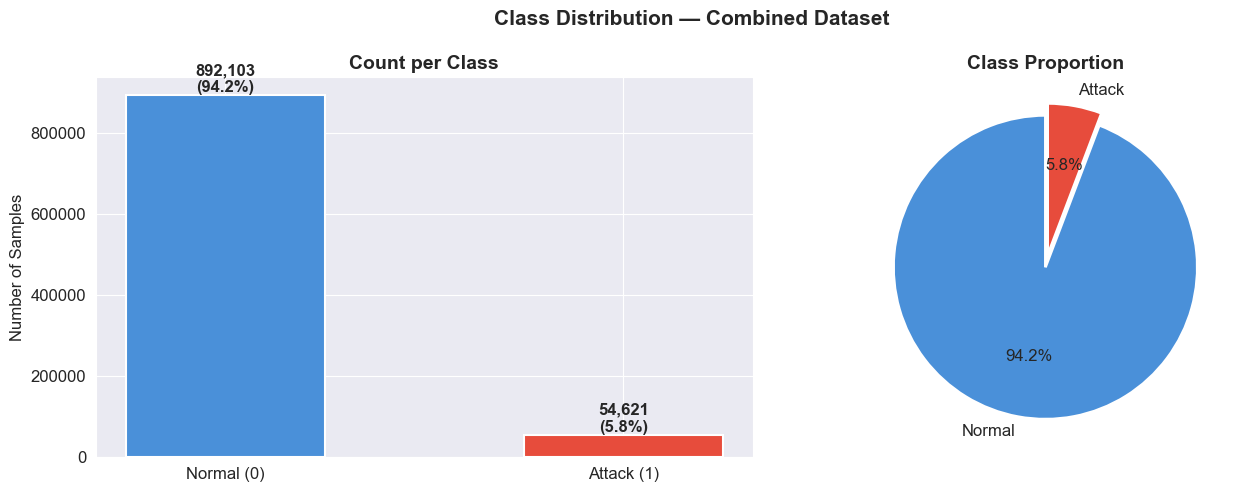


⚠️  IMBALANCE ALERT: Attack samples = 5.8% of total
   → Use Precision / Recall / F1-Score, NOT Accuracy as evaluation metric!


In [ ]:
# 3.2 Class Distribution Plot 
df_combined = pd.concat([df_normal, df_attack])
label_counts = df_combined['label'].value_counts()
label_pct    = df_combined['label'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution — Combined Dataset', fontsize=15, fontweight='bold')

# Bar chart
bars = axes[0].bar(['Normal (0)', 'Attack (1)'], label_counts.values,
                   color=[C_NORMAL, C_ATTACK], edgecolor='white', linewidth=1.5, width=0.5)
for bar, count, pct in zip(bars, label_counts.values, label_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Count per Class')
axes[0].set_ylabel('Number of Samples')

# Pie chart
axes[1].pie(label_counts.values, labels=['Normal', 'Attack'],
            colors=[C_NORMAL, C_ATTACK], autopct='%1.1f%%',
            startangle=90, explode=[0, 0.08],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('plot_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n⚠️  IMBALANCE ALERT: Attack samples = {label_pct.get(1, 0):.1f}% of total')
print('   → Use Precision / Recall / F1-Score, NOT Accuracy as evaluation metric!')

---
## 4️⃣ Sensor Profiling

In [ ]:
# 4.1 Identify Sensor vs Actuator Columns 
drop_cols = ['label', label_col] if label_col else ['label']
feature_cols = [c for c in df_combined.columns if c not in drop_cols
                and 'unnamed' not in c.lower()]

df_features = df_combined[feature_cols].copy()

# Binary = <= 3 unique values → actuators (ON/OFF/FAULT)
binary_cols     = [c for c in df_features.columns if df_features[c].nunique() <= 3]
continuous_cols = [c for c in df_features.columns if c not in binary_cols]

print(f'📡 Feature Summary:')
print(f'   Total features       : {len(feature_cols)}')
print(f'   Continuous (sensors) : {len(continuous_cols)}')
print(f'   Binary (actuators)   : {len(binary_cols)}')
print(f'\n🔵 Continuous sensors  : {continuous_cols}')
print(f'\n🟠 Binary actuators    : {binary_cols}')

📡 Feature Summary:
   Total features       : 51
   Continuous (sensors) : 25
   Binary (actuators)   : 26

🔵 Continuous sensors  : ['FIT101', 'LIT101', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'DPIT301', 'FIT301', 'LIT301', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'PIT501', 'PIT502', 'PIT503', 'FIT601']

🟠 Binary actuators    : ['MV101', 'P101', 'P102', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'P401', 'P402', 'P403', 'P404', 'UV401', 'P501', 'P502', 'P601', 'P602', 'P603']


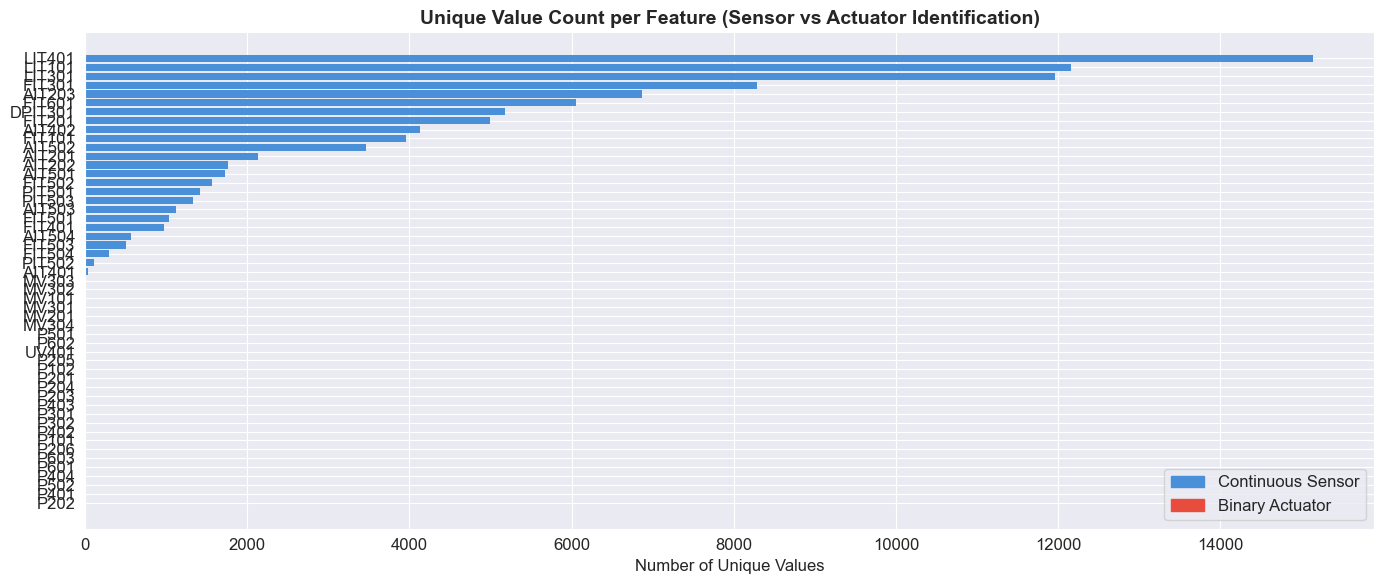

In [ ]:
# 4.2 Sensor Unique Value Counts (sanity check) 
unique_counts = df_features.nunique().sort_values()

fig, ax = plt.subplots(figsize=(14, 6))
colors = [C_ATTACK if c in binary_cols else C_NORMAL for c in unique_counts.index]
bars = ax.barh(unique_counts.index, unique_counts.values, color=colors, edgecolor='none')

# Legend
ax.legend(handles=[
    mpatches.Patch(color=C_NORMAL, label='Continuous Sensor'),
    mpatches.Patch(color=C_ATTACK, label='Binary Actuator')
], loc='lower right')

ax.set_xlabel('Number of Unique Values')
ax.set_title('Unique Value Count per Feature (Sensor vs Actuator Identification)')
plt.tight_layout()
plt.savefig('plot_02_sensor_profiling.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5️⃣ EDA & Visualizations

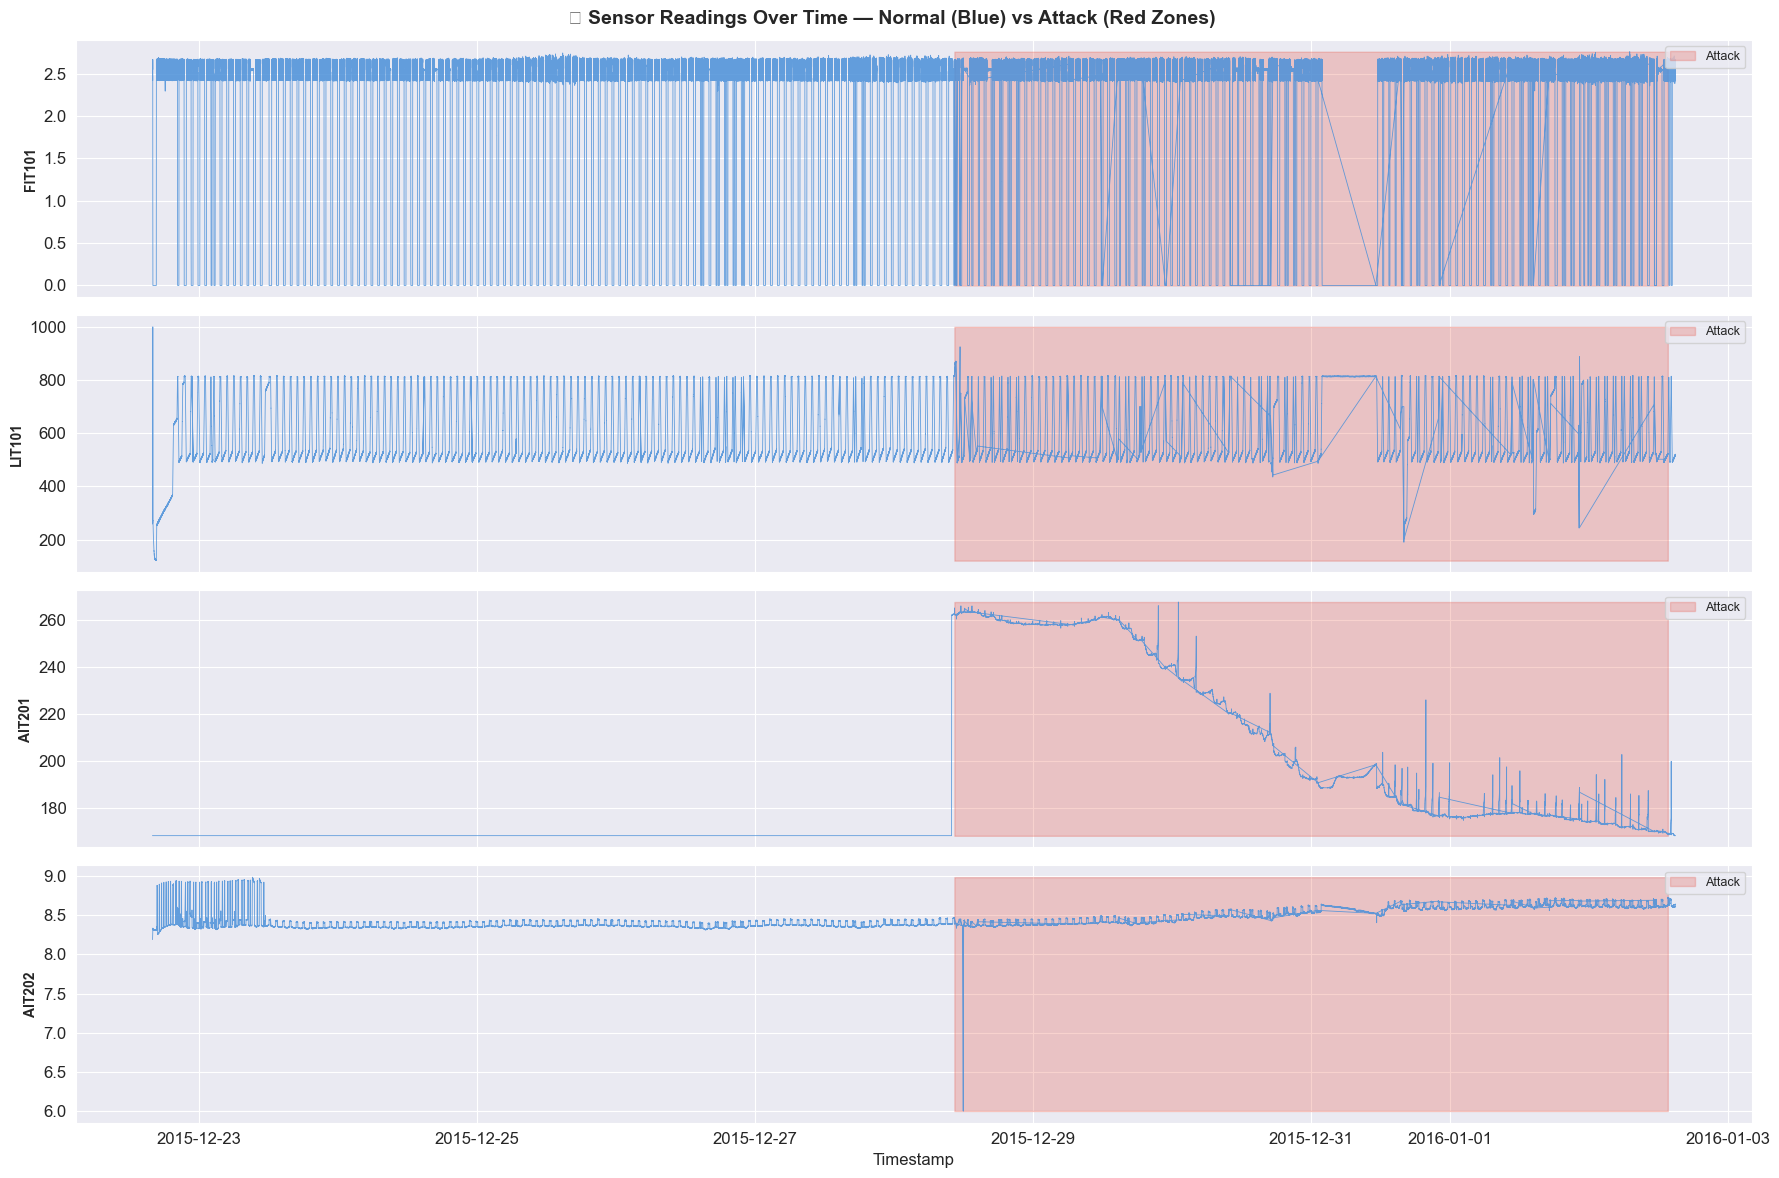

In [ ]:
# 5.1 Time Series — Top 4 Sensors with Attack Overlay 
plot_sensors = continuous_cols[:4]
df_plot = df_combined[plot_sensors + ['label']].copy()

fig, axes = plt.subplots(len(plot_sensors), 1, figsize=(18, 12), sharex=True)
fig.suptitle('📈 Sensor Readings Over Time — Normal (Blue) vs Attack (Red Zones)',
             fontsize=14, fontweight='bold')

for i, col in enumerate(plot_sensors):
    ax = axes[i]
    ax.plot(df_plot.index, df_plot[col], color=C_NORMAL, linewidth=0.6, alpha=0.85)
    
    # Shade attack windows
    attack_mask = df_plot['label'] == 1
    ymin, ymax  = df_plot[col].min(), df_plot[col].max()
    ax.fill_between(df_plot.index, ymin, ymax,
                    where=attack_mask, color=C_ATTACK, alpha=0.25, label='Attack')
    
    ax.set_ylabel(col, fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Timestamp')
plt.tight_layout()
plt.savefig('plot_03_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

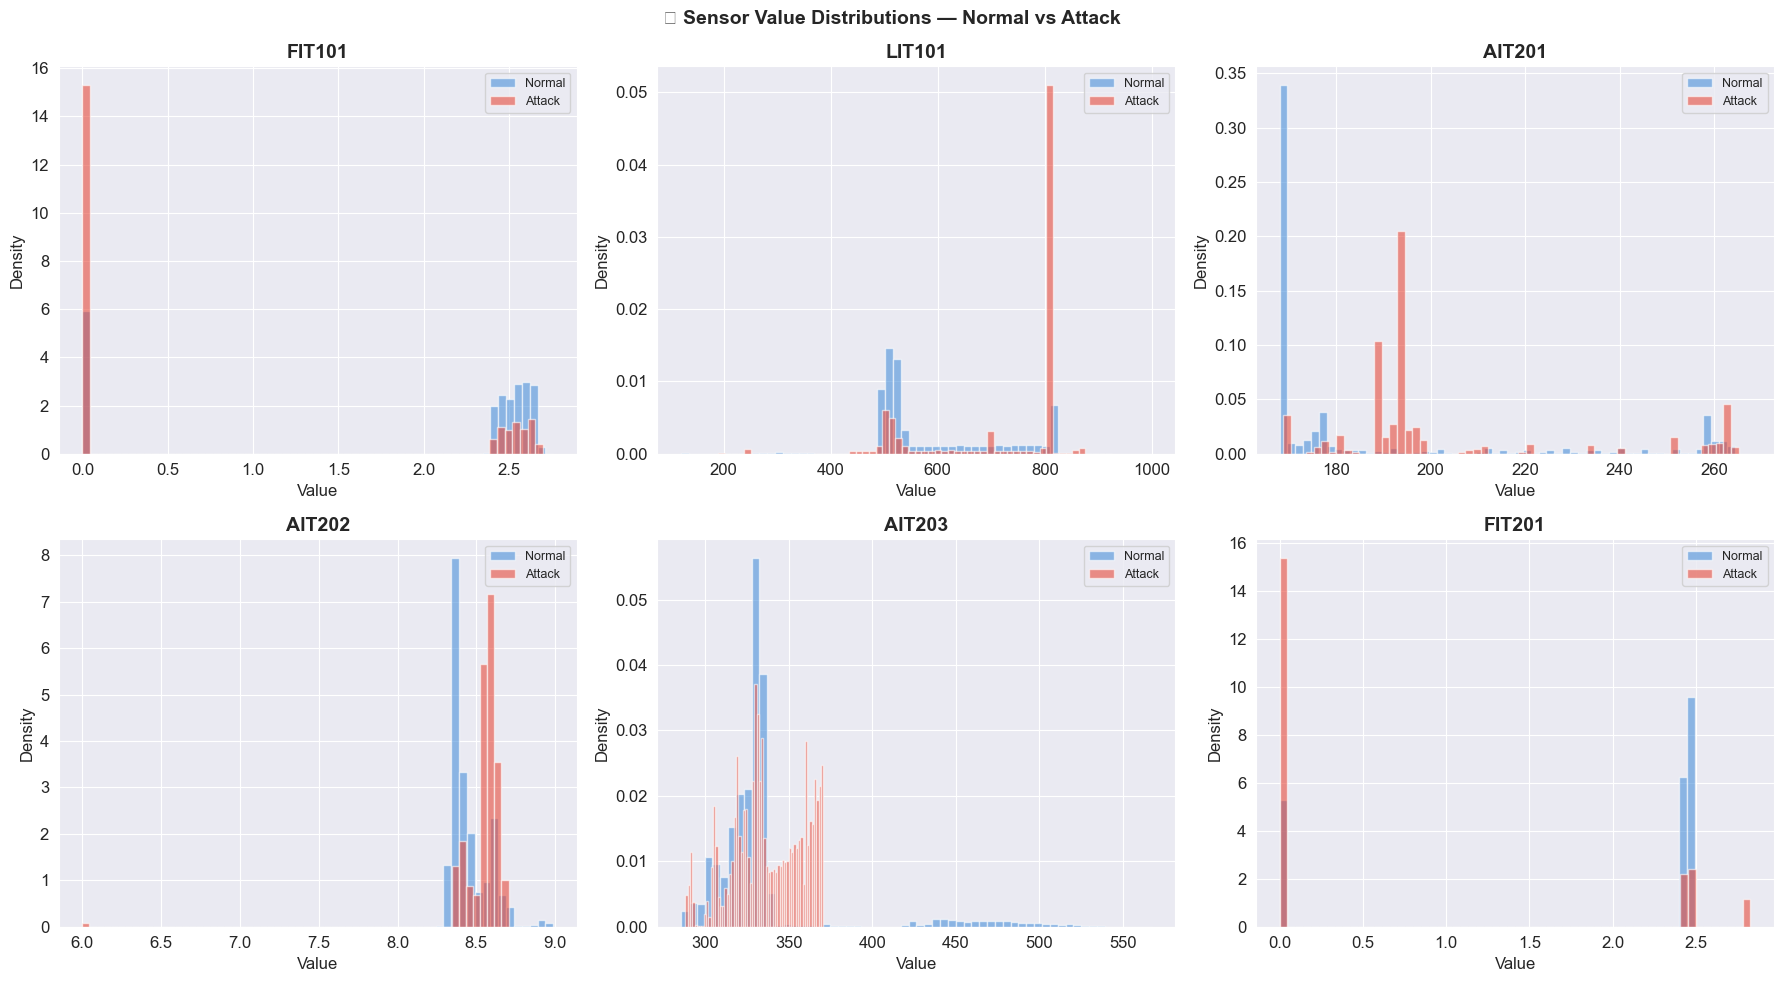

In [ ]:
# 5.2 Distribution Plots — Normal vs Attack 
plot_sensors_dist = continuous_cols[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Sensor Value Distributions — Normal vs Attack', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(plot_sensors_dist):
    normal_vals = df_combined[df_combined['label'] == 0][col].dropna()
    attack_vals = df_combined[df_combined['label'] == 1][col].dropna()
    
    axes[i].hist(normal_vals, bins=60, alpha=0.6, color=C_NORMAL,
                 label='Normal', density=True)
    axes[i].hist(attack_vals, bins=60, alpha=0.6, color=C_ATTACK,
                 label='Attack', density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_04_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

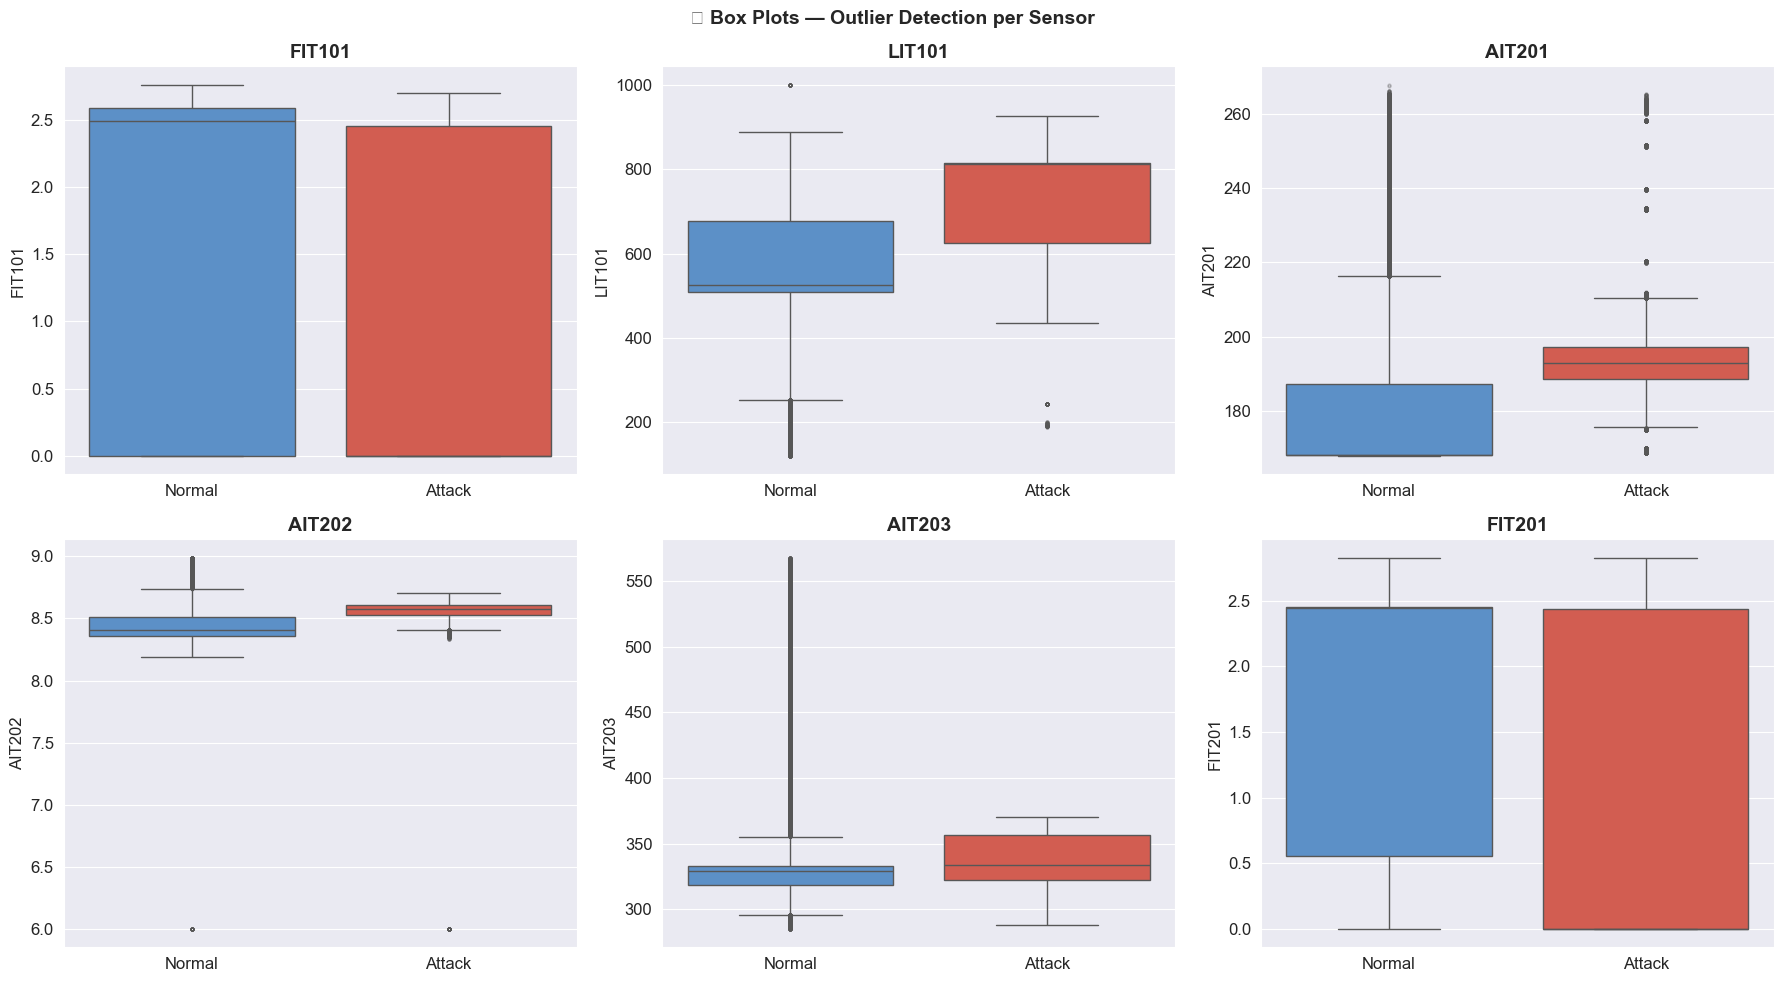

In [ ]:
# 5.3 Box Plots — Outlier Detection 
plot_sensors_box = continuous_cols[:6]
df_box = df_combined[plot_sensors_box + ['label']].copy()
df_box['label'] = df_box['label'].map({0: 'Normal', 1: 'Attack'})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📦 Box Plots — Outlier Detection per Sensor', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(plot_sensors_box):
    sns.boxplot(data=df_box, x='label', y=col, ax=axes[i],
                palette={'Normal': C_NORMAL, 'Attack': C_ATTACK},
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('plot_05_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

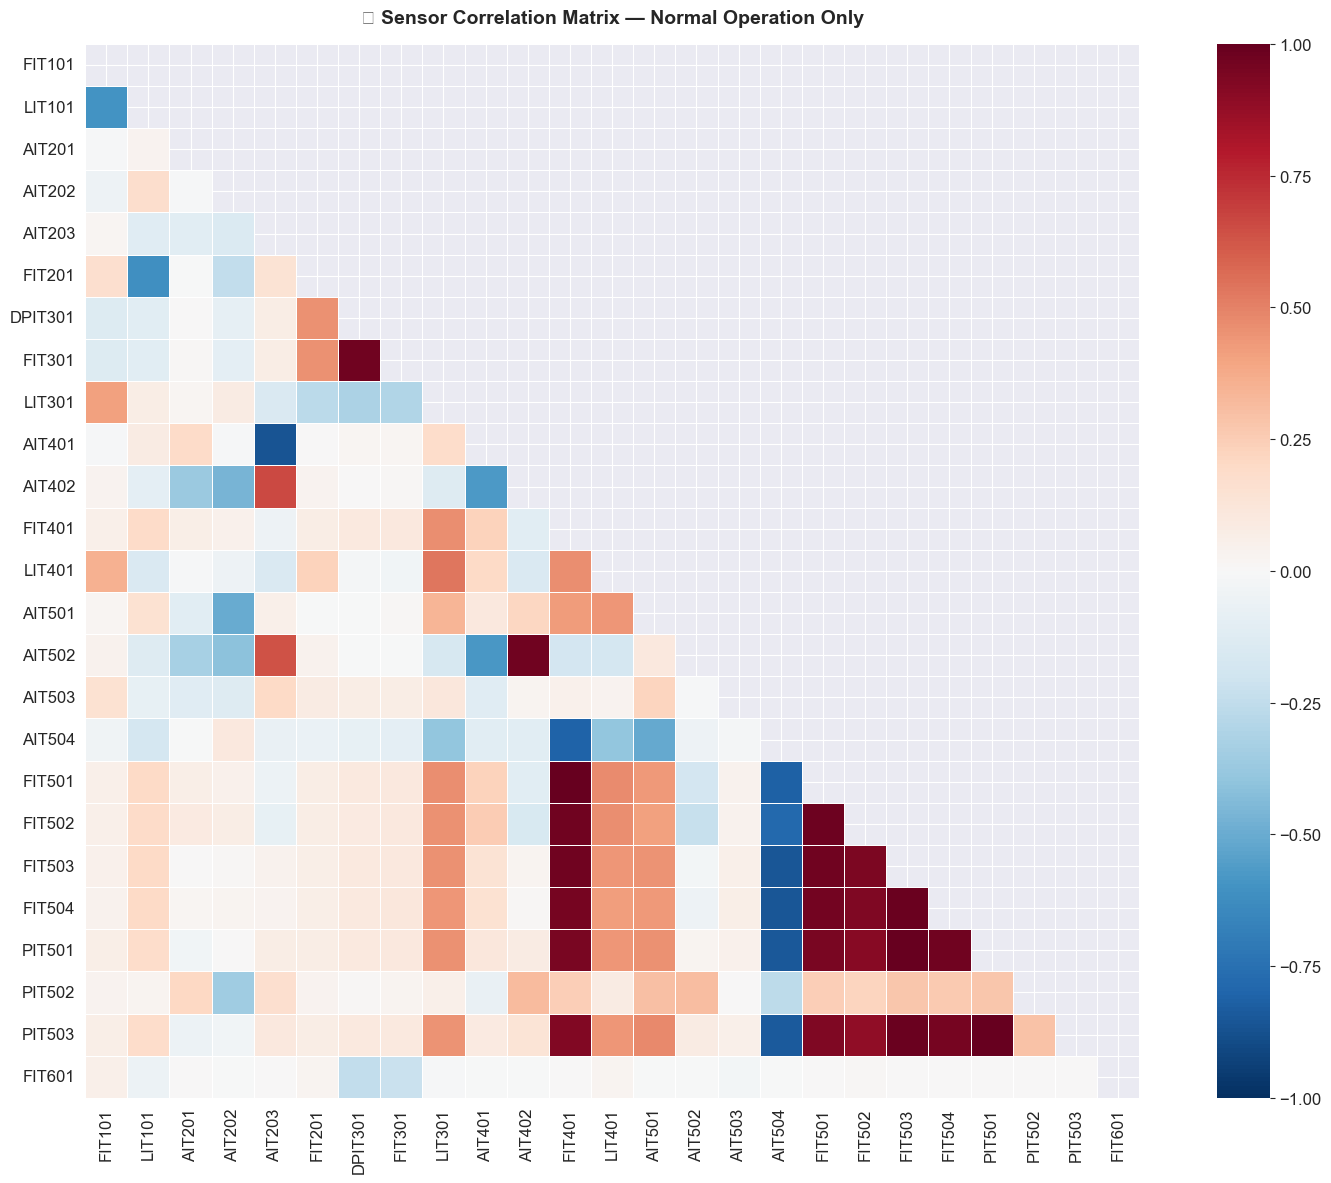

🔗 Top 10 Correlated Sensor Pairs (Normal Operation):
PIT503  PIT501     0.998
FIT501  FIT401     0.993
PIT501  FIT503     0.992
FIT504  FIT503     0.990
PIT503  FIT503     0.985
FIT502  FIT501     0.982
        FIT401     0.975
FIT301  DPIT301    0.975
AIT502  AIT402     0.975
FIT503  FIT501     0.974


In [ ]:
# 5.4 Correlation Heatmap (Normal Operation Only)
df_normal_only = df_combined[df_combined['label'] == 0][continuous_cols]
corr_matrix    = df_normal_only.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show only lower triangle

sns.heatmap(
    corr_matrix, mask=mask,
    cmap='RdBu_r', center=0,
    linewidths=0.4, linecolor='white',
    annot=(len(continuous_cols) <= 15),   # only annotate if ≤15 sensors
    fmt='.2f', annot_kws={'size': 8},
    vmin=-1, vmax=1,
    square=True
)
plt.title('🔗 Sensor Correlation Matrix — Normal Operation Only',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlated pairs
corr_pairs = (corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
              .stack().sort_values(ascending=False))
print('🔗 Top 10 Correlated Sensor Pairs (Normal Operation):')
print(corr_pairs.head(10).round(3).to_string())

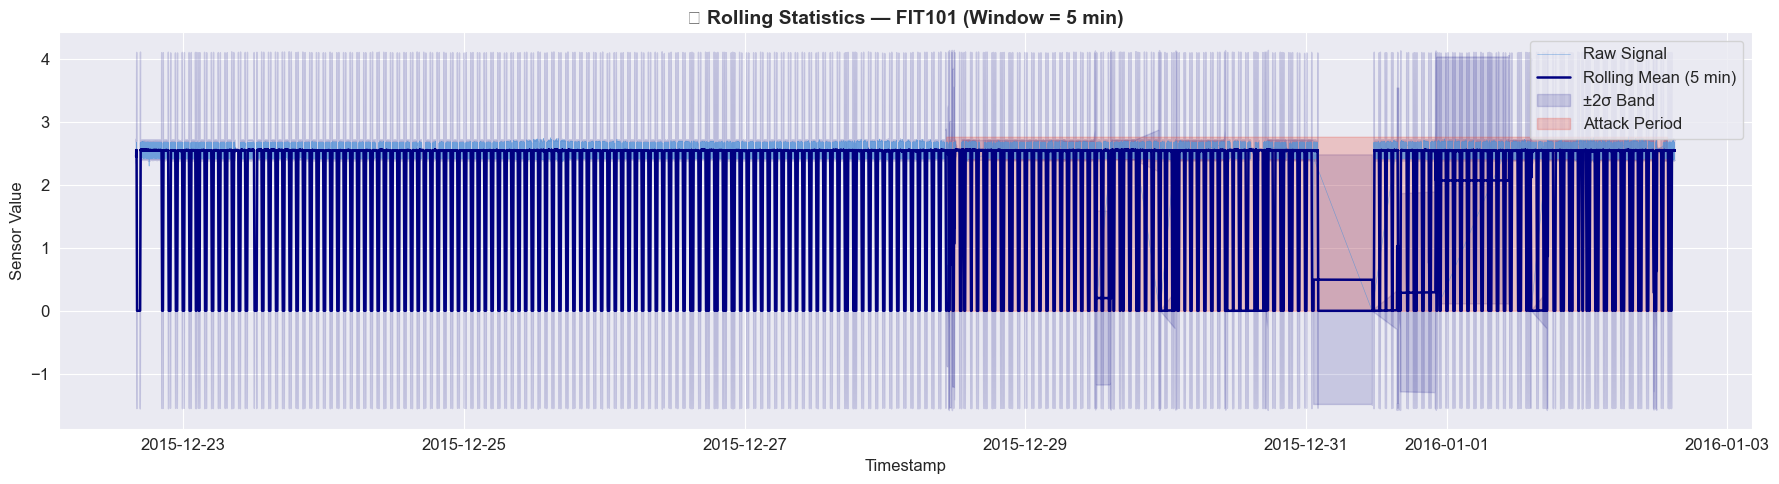

In [ ]:
# 5.5 Rolling Statistics — Drift Detection 
sensor = continuous_cols[0]   # ← change to inspect any sensor
series = df_combined[sensor]

roll_mean = series.rolling(window=300, min_periods=1).mean()
roll_std  = series.rolling(window=300, min_periods=1).std().fillna(0)

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(series.index, series,     color=C_NORMAL, linewidth=0.4, alpha=0.7, label='Raw Signal')
ax.plot(roll_mean.index, roll_mean, color='navy', linewidth=1.8, label='Rolling Mean (5 min)')
ax.fill_between(series.index,
                roll_mean - 2*roll_std,
                roll_mean + 2*roll_std,
                alpha=0.15, color='navy', label='±2σ Band')

attack_mask = df_combined['label'] == 1
ax.fill_between(series.index, series.min(), series.max(),
                where=attack_mask, color=C_ATTACK, alpha=0.25, label='Attack Period')

ax.set_title(f'📉 Rolling Statistics — {sensor} (Window = 5 min)', fontweight='bold')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Sensor Value')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('plot_07_rolling_stats.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6️⃣ Anomaly Pattern Analysis

In [ ]:
# 6.1 Statistical Comparison — Normal vs Attack 
df_stat = df_combined[continuous_cols + ['label']].copy()

stats_n = df_stat[df_stat['label']==0][continuous_cols].describe().T[['mean','std']]
stats_a = df_stat[df_stat['label']==1][continuous_cols].describe().T[['mean','std']]

stats_n.columns = ['normal_mean', 'normal_std']
stats_a.columns = ['attack_mean', 'attack_std']

comparison = pd.concat([stats_n, stats_a], axis=1)
comparison['mean_shift_%'] = (
    abs(comparison['attack_mean'] - comparison['normal_mean']) /
    (comparison['normal_mean'].abs() + 1e-9) * 100
).round(2)
comparison['std_change_%'] = (
    abs(comparison['attack_std'] - comparison['normal_std']) /
    (comparison['normal_std'].abs() + 1e-9) * 100
).round(2)

comparison_sorted = comparison.sort_values('mean_shift_%', ascending=False)

print('🔍 Top 10 Most Affected Sensors During Attacks (by mean shift):')
display(comparison_sorted.head(10).style
        .background_gradient(cmap='OrRd', subset=['mean_shift_%', 'std_change_%'])
        .format('{:.3f}'))

🔍 Top 10 Most Affected Sensors During Attacks (by mean shift):


,normal_mean,normal_std,attack_mean,attack_std,mean_shift_%,std_change_%
FIT301,1.844,0.810,0.663,1.005,64.040,23.990
FIT201,1.835,1.060,0.689,1.125,62.440,6.100
FIT504,0.306,0.019,0.118,0.149,61.490,669.190
FIT401,1.707,0.105,0.668,0.828,60.860,685.160
FIT503,0.733,0.045,0.293,0.353,60.080,682.170
PIT502,1.142,0.262,0.463,0.631,59.410,140.430
FIT501,1.717,0.105,0.702,0.836,59.130,696.040
FIT502,1.277,0.080,0.524,0.624,58.980,678.760
PIT503,189.269,11.643,78.508,89.256,58.520,666.610
PIT501,250.299,14.952,106.718,115.682,57.360,673.690


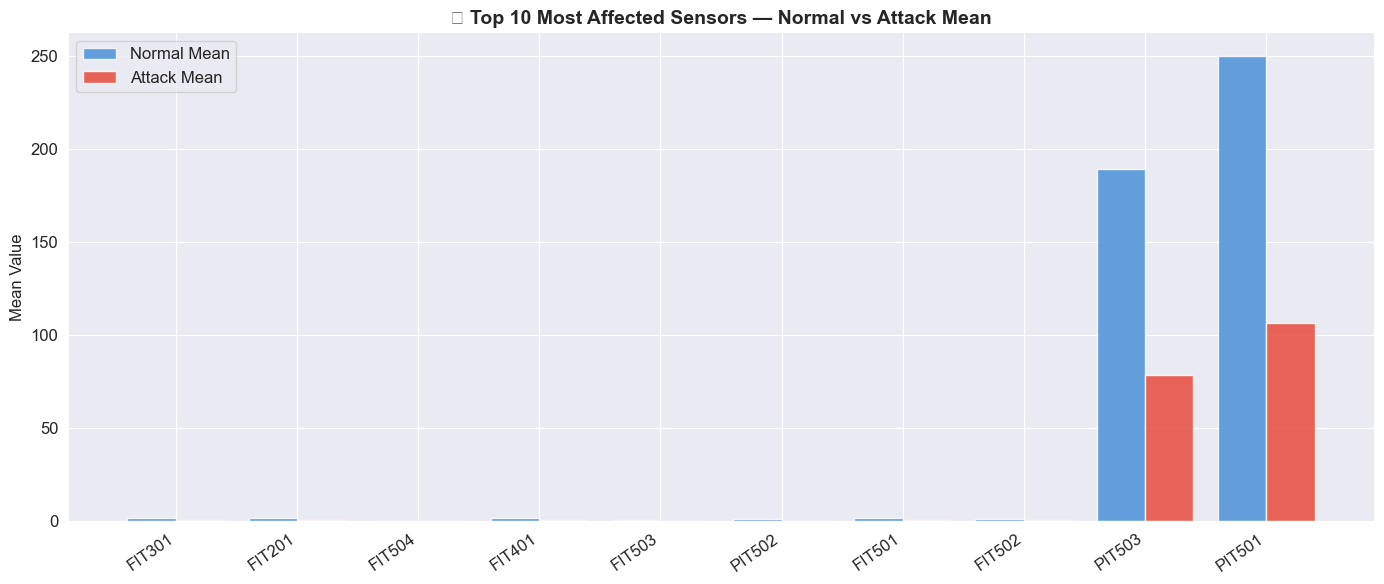

In [ ]:
# 6.2 Most Affected Sensors — Bar Chart 
top10 = comparison_sorted.head(10)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(top10))
width = 0.4

ax.bar(x - width/2, top10['normal_mean'], width, label='Normal Mean',
       color=C_NORMAL, alpha=0.85, edgecolor='white')
ax.bar(x + width/2, top10['attack_mean'], width, label='Attack Mean',
       color=C_ATTACK, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(top10.index, rotation=35, ha='right')
ax.set_title('🎯 Top 10 Most Affected Sensors — Normal vs Attack Mean', fontweight='bold')
ax.set_ylabel('Mean Value')
ax.legend()
plt.tight_layout()
plt.savefig('plot_08_affected_sensors.png', dpi=150, bbox_inches='tight')
plt.show()

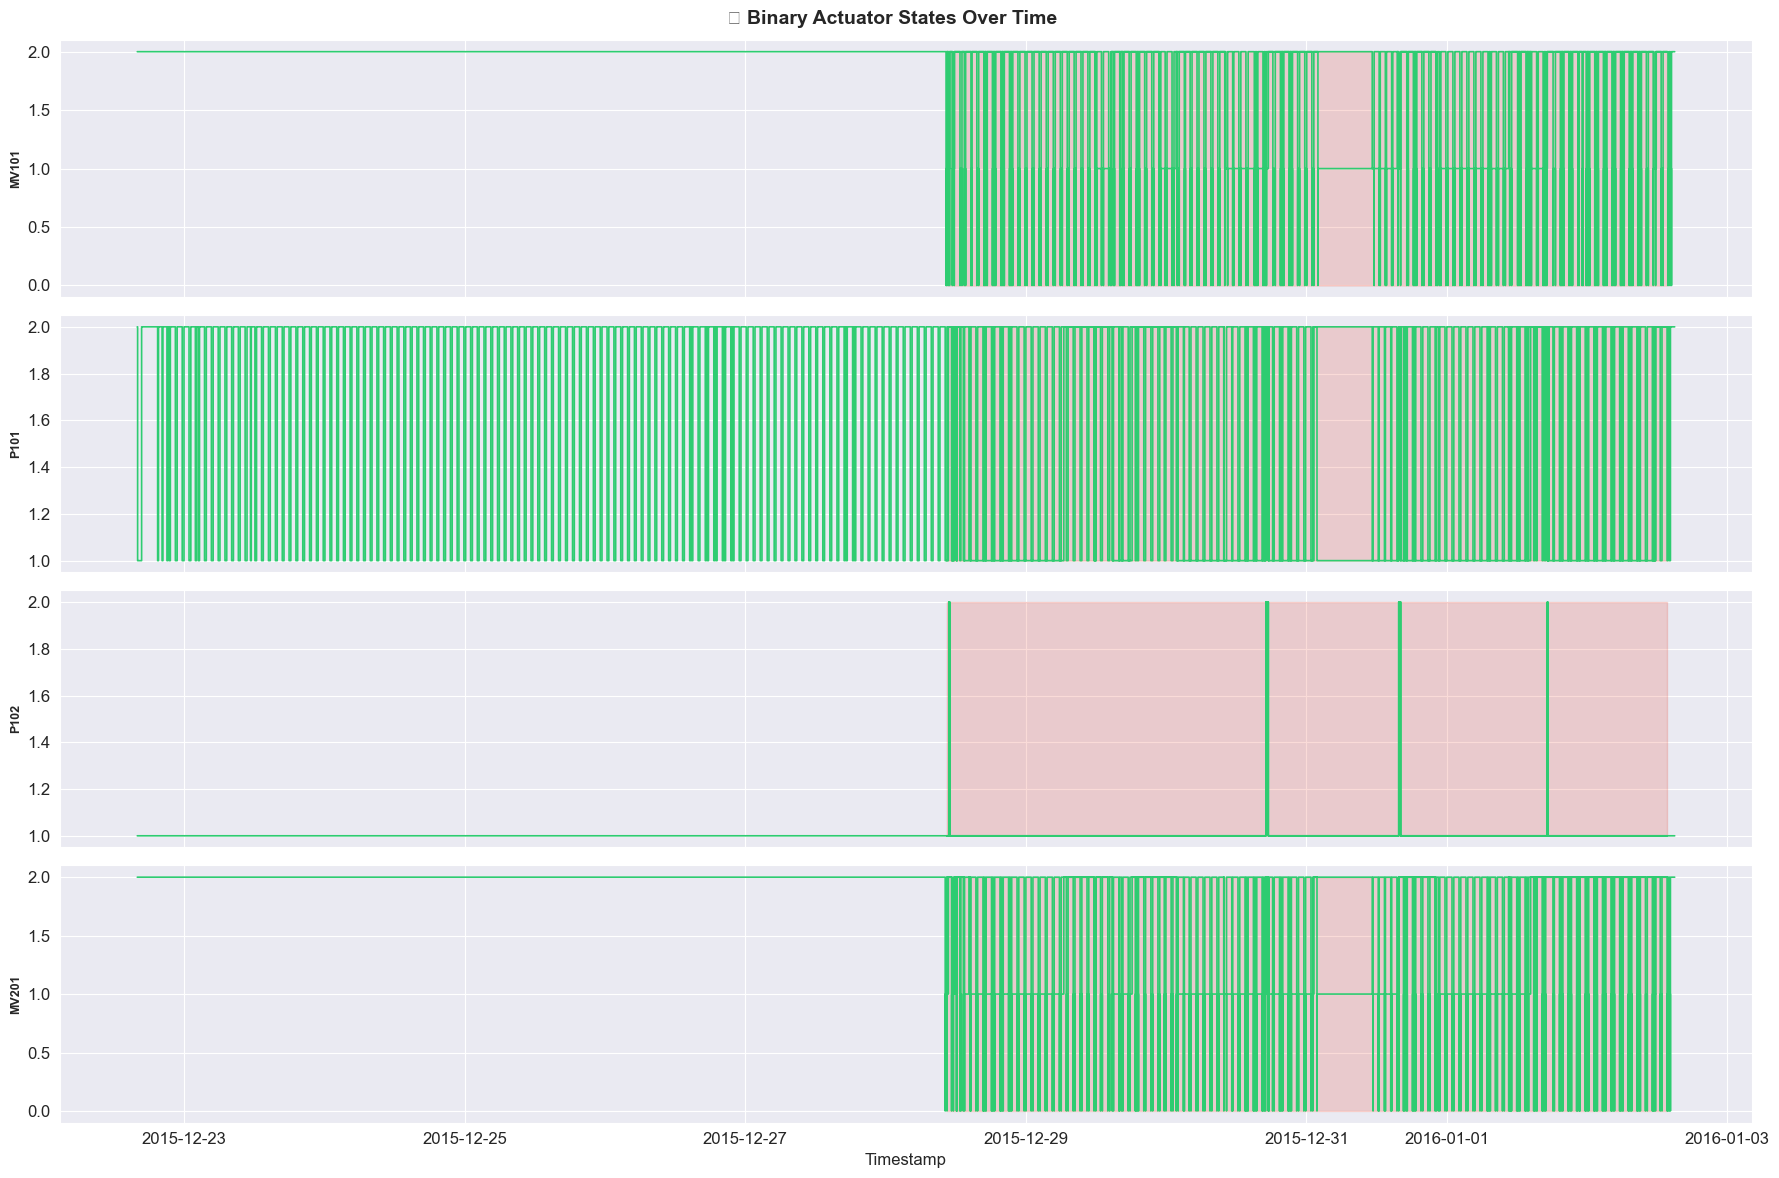

In [ ]:
# 6.3 Actuator State Changes During Attacks 
if binary_cols:
    fig, axes = plt.subplots(min(4, len(binary_cols)), 1,
                             figsize=(18, 3 * min(4, len(binary_cols))), sharex=True)
    fig.suptitle('🔧 Binary Actuator States Over Time', fontsize=14, fontweight='bold')

    if len(binary_cols) == 1:
        axes = [axes]

    for i, col in enumerate(binary_cols[:4]):
        ax = axes[i]
        ax.step(df_combined.index, df_combined[col],
                color=C_ACCENT, linewidth=1.2, where='post')

        attack_mask = df_combined['label'] == 1
        ax.fill_between(df_combined.index, df_combined[col].min(), df_combined[col].max(),
                        where=attack_mask, color=C_ATTACK, alpha=0.2)
        ax.set_ylabel(col, fontsize=9, fontweight='bold')

    axes[-1].set_xlabel('Timestamp')
    plt.tight_layout()
    plt.savefig('plot_09_actuator_states.png', dpi=150, bbox_inches='tight')
    plt.show()